# Nykaa Marketing Campaign ROI Prediction
## Objective
### The goal of this project is to analyze marketing campaign data and build a machine learning model to predict Return on Investment (ROI).

In [134]:
import pandas as pd
import numpy as np

## Data Loading

In [137]:
data=pd.read_csv("C:/Users/LENOVO/Downloads/nykaa_campaign_data.csv")
data

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55550,NY-CMP-56550,SEO,Youth,16,"Instagram, Email",31041,3849,1012,639,162945,374.90,-0.32,Tamil,17.72,Tier 2 City Customers,16-02-2025
55551,NY-CMP-56551,Paid Ads,Tier 2 City Customers,26,Facebook,27335,3715,2184,1006,792728,56.38,12.98,English,25.26,Premium Shoppers,18-11-2024
55552,NY-CMP-56552,Influencer,Tier 2 City Customers,23,"WhatsApp, Facebook, Instagram",43481,6447,3751,1668,383640,56.18,3.09,Bengali,27.29,Working Women,24-10-2024
55553,NY-CMP-56553,Social Media,College Students,16,"Facebook, Email",33530,2518,584,299,194051,227.53,1.85,Bengali,10.14,Working Women,22-05-2025


## Removing Identifier Column

### The `Campaign_ID` column is a unique identifier and does not contribute to predicting ROI.  
### Hence, it is removed from the dataset.

In [140]:
data.drop("Campaign_ID", axis=1, inplace=True)

## Data Understanding
### We explore the dataset structure, data types, and statistical summary to understand the distribution of features.

In [143]:
print(data.shape)

(55555, 15)


In [145]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_Type     55555 non-null  object 
 1   Target_Audience   55555 non-null  object 
 2   Duration          55555 non-null  int64  
 3   Channel_Used      55555 non-null  object 
 4   Impressions       55555 non-null  int64  
 5   Clicks            55555 non-null  int64  
 6   Leads             55555 non-null  int64  
 7   Conversions       55555 non-null  int64  
 8   Revenue           55555 non-null  int64  
 9   Acquisition_Cost  55555 non-null  float64
 10  ROI               55555 non-null  float64
 11  Language          55555 non-null  object 
 12  Engagement_Score  55555 non-null  float64
 13  Customer_Segment  55555 non-null  object 
 14  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(6)
memory usage: 6.4+ MB
None


In [147]:
print(data.describe())

           Duration    Impressions        Clicks         Leads   Conversions  \
count  55555.000000   55555.000000  55555.000000  55555.000000  55555.000000   
mean      17.446044   55087.885357   4688.070507   1877.271119   1032.866925   
std        7.520438   25930.001514   3178.686285   1435.636117    862.496788   
min        5.000000   10001.000000    202.000000     56.000000     19.000000   
25%       11.000000   32680.000000   2110.000000    779.000000    400.000000   
50%       17.000000   55182.000000   3907.000000   1481.000000    779.000000   
75%       24.000000   77514.500000   6688.000000   2605.000000   1414.000000   
max       30.000000  100000.000000  14868.000000   8876.000000   6686.000000   

            Revenue  Acquisition_Cost           ROI  Engagement_Score  
count  5.555500e+04      55555.000000  55555.000000      55555.000000  
mean   5.158197e+05        377.347068      2.713807         13.784169  
std    4.900121e+05        541.084524      4.493380          6.

## Feature Engineering
### New features are created to capture campaign efficiency:
### - CTR (Click Through Rate): Measures how many users clicked on the ad after seeing it.  
### - Conversion Rate: Measures how many users completed the desired action after clicking the ad.  
### - Lead Conversion Rate: Measures how many leads actually converted into customers.  
### These features help evaluate performance across different stages of the marketing funnel and are important for predicting ROI.

In [150]:
data['CTR'] = data['Clicks'] / (data['Impressions'] + 1)
data['Conversion_Rate'] = data['Conversions'] / (data['Clicks'] + 1)
data['Lead_Conversion'] = data['Conversions'] / (data['Leads'] + 1)

In [152]:
data['CTR_bins'] = pd.cut(data['CTR'], bins=5)
data['CR_bins'] = pd.cut(data['Conversion_Rate'], bins=5)
data['LC_bins'] = pd.cut(data['Lead_Conversion'], bins=5)

In [154]:
ctr_impact = data.groupby('CTR_bins')['ROI'].mean()
cr_impact = data.groupby('CR_bins')['ROI'].mean()
lc_impact = data.groupby('LC_bins')['ROI'].mean()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13384\2779754892.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctr_impact = data.groupby('CTR_bins')['ROI'].mean()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13384\2779754892.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cr_impact = data.groupby('CR_bins')['ROI'].mean()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13384\2779754892.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sile

## Impact of Engineered Features on ROI
### We grouped CTR, Conversion Rate, and Lead Conversion into bins (low → high) and calculated the average ROI for each bin.  
### The line graph shows that higher Conversion Rate and CTR generally lead to higher ROI, while Lead Conversion has a more gradual impact.  
### This demonstrates that both attracting clicks (CTR) and successfully converting users (Conversion Rate, Lead Conversion) are key drivers of campaign ROI.

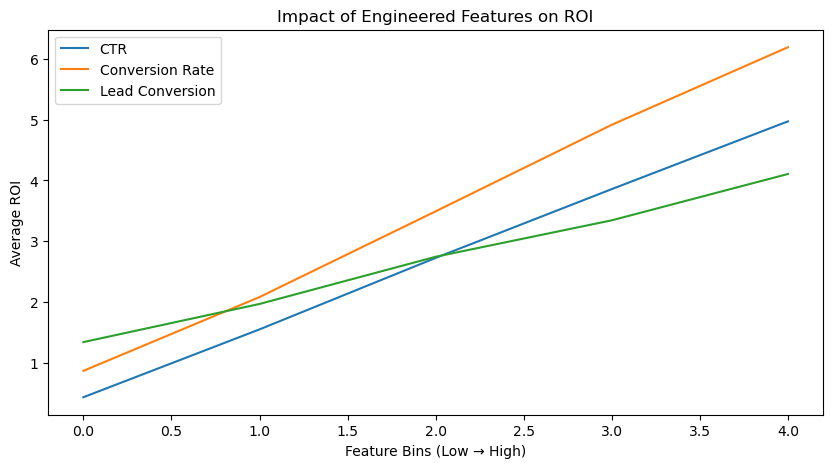

In [157]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(ctr_impact.values, label='CTR')
plt.plot(cr_impact.values, label='Conversion Rate')
plt.plot(lc_impact.values, label='Lead Conversion')
plt.title("Impact of Engineered Features on ROI")
plt.xlabel("Feature Bins (Low → High)")
plt.ylabel("Average ROI")
plt.legend()
plt.show()

##  ROI Distribution and Data Cleaning
### We plotted a histogram of ROI to understand its distribution.  
### The ROI values are mostly right-skewed, with the majority lying between 0 and 30, and a few extreme high values.  

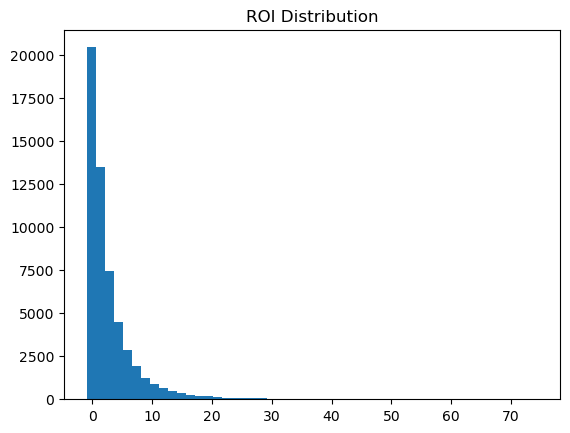

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(data['ROI'], bins=50)
plt.title("ROI Distribution")
plt.show()

##  Outlier Handling (IQR Method)
### We calculated the interquartile range (IQR) for ROI and capped values outside 1.5 times the IQR from Q1 and Q3. This ensures extreme ROI values (outliers) do not disproportionately influence the model.

In [163]:
q1 = data['ROI'].quantile(0.25)
q3 = data['ROI'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
data['ROI'] = np.clip(data['ROI'], lower, upper)

## Log Transformation of ROI
### Applied a log transformation to the ROI values to reduce right skewness and stabilize variance. This helps in improving model performance and handling extreme values effectively.

In [166]:
data['ROI'] = np.log1p(data['ROI'])

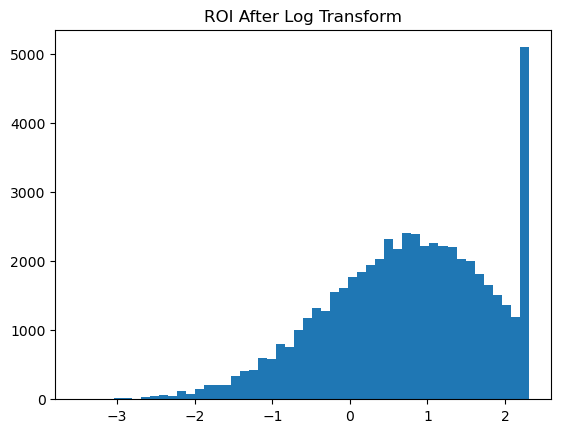

In [168]:
plt.hist(data['ROI'], bins=50)
plt.title("ROI After Log Transform")
plt.show()

## Correlation Analysis

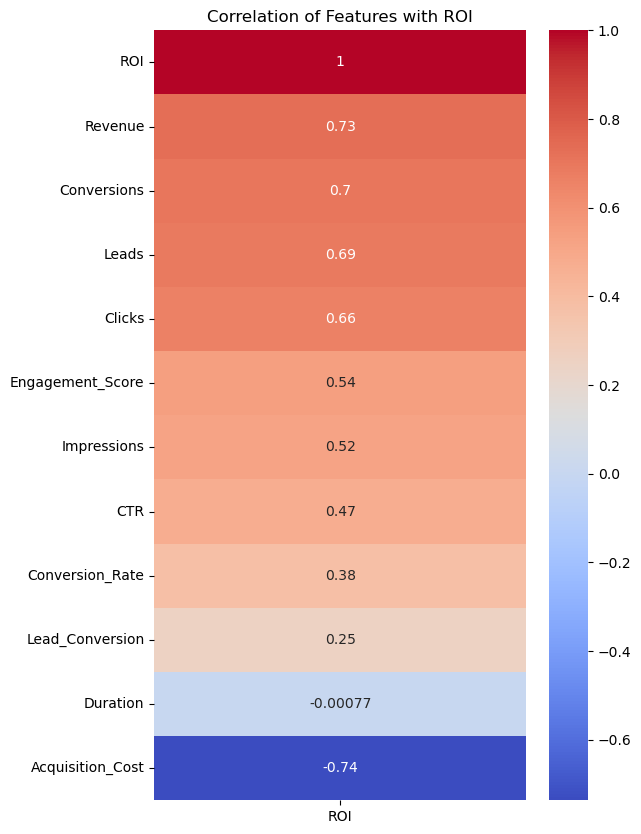

In [171]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])
roi_corr = numeric_data.corr()[['ROI']].sort_values(by='ROI', ascending=False)
plt.figure(figsize=(6,10))
sns.heatmap(roi_corr, annot=True, cmap='coolwarm')
plt.title("Correlation of Features with ROI")
plt.show()

### Correlation Analysis
### After analyzing the correlation heatmap, we observed the following insights:  
### - **Revenue** shows a strong positive correlation with ROI (≈ 0.81), indicating that higher revenue campaigns generally yield higher ROI.  
### - **Acquisition Cost** has a moderate negative correlation with ROI (≈ -0.48), suggesting that campaigns with higher costs tend to have slightly lower ROI.  
### - **Duration** exhibits an almost negligible correlation with ROI (≈-0.0014).  
### Based on these observations, **Duration** can be safely removed from the dataset as it provides little predictive value, whereas Acquisition Cost is retained due to its meaningful relationship with ROI.

In [174]:
data = data.drop('Duration', axis=1)

## ROI by Campaign Type
### Average ROI was calculated for each campaign type. It is lowest for **Email**, followed by **Paid Ads**, **Influencer**, **SEO**, and highest for **Social Media** campaigns.

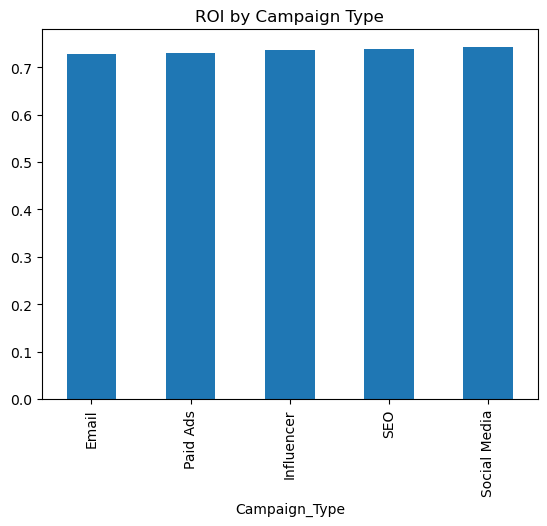

In [177]:
data.groupby('Campaign_Type')['ROI'].mean().sort_values().plot(kind='bar')
plt.title("ROI by Campaign Type")
plt.show()

## Extract Year from Date
### The `Date` column was split to extract the **year** of each campaign.  
### We removed the original `Date` column after extraction to simplify the dataset.

In [180]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data['Year'] = data['Date'].dt.year

In [182]:
data.drop('Date', axis=1, inplace=True)

## Channel Encoding
### Campaigns used multiple channels in a single column.  
### We separated channels using one-hot encoding to create individual **binary columns** for each channel.  
### The original `Channel_Used` column was removed to avoid redundancy.

In [185]:
channel_dummies = data['Channel_Used'].str.get_dummies(sep=', ')
data = pd.concat([data, channel_dummies], axis=1)

In [187]:
if 'Channel_Used' in data.columns:
    data.drop('Channel_Used', axis=1, inplace=True)

In [189]:
print(data.select_dtypes(include='object').columns)

Index(['Campaign_Type', 'Target_Audience', 'Language', 'Customer_Segment'], dtype='object')


### Encode Remaining Categorical Features

In [192]:
data = pd.get_dummies(data, drop_first=True)

In [194]:
print(data.select_dtypes(include='object').columns)

Index([], dtype='object')


In [196]:
print(data.head())

   Impressions  Clicks  Leads  Conversions  Revenue  Acquisition_Cost  \
0        57804    6156   3616         2355  1867515            111.03   
1        91801    3321   1971         1357  1046247            180.83   
2        15536    2182    952          755   197055             90.60   
3        88114    8413   2231          947   376906            249.07   
4        96871    3743   2060         1258   518296            228.60   

        ROI  Engagement_Score       CTR  Conversion_Rate  ...  \
0  1.965713             20.98  0.106496         0.382491  ...   
1  1.449269              7.24  0.036176         0.408489  ...   
2  1.057790             25.03  0.140439         0.345854  ...   
3  0.470004             13.15  0.095478         0.112551  ...   
4  0.587787              7.29  0.038639         0.336004  ...   

   CTR_bins_(0.098, 0.124]  CTR_bins_(0.124, 0.15]  CR_bins_(0.143, 0.227]  \
0                     True                   False                   False   
1             

### Remove Binned Features
### Bins created during feature engineering (`CTR_bins`, `CR_bins`, `LC_bins`) were removed.  
### These columns were not needed for modeling and could introduce noise.

In [199]:
cols_to_drop = [col for col in data.columns if 'bins' in col]
data.drop(columns=cols_to_drop, inplace=True)

In [201]:
data.columns

Index(['Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue',
       'Acquisition_Cost', 'ROI', 'Engagement_Score', 'CTR', 'Conversion_Rate',
       'Lead_Conversion', 'Year', 'Email', 'Facebook', 'Google', 'Instagram',
       'WhatsApp', 'YouTube', 'Campaign_Type_Influencer',
       'Campaign_Type_Paid Ads', 'Campaign_Type_SEO',
       'Campaign_Type_Social Media', 'Target_Audience_Premium Shoppers',
       'Target_Audience_Tier 2 City Customers',
       'Target_Audience_Working Women', 'Target_Audience_Youth',
       'Language_English', 'Language_Hindi', 'Language_Tamil',
       'Customer_Segment_Premium Shoppers',
       'Customer_Segment_Tier 2 City Customers',
       'Customer_Segment_Working Women', 'Customer_Segment_Youth'],
      dtype='object')

### Train-Test Split
### The dataset was divided into training and testing sets (80-20 split).  
### ROI` is used as the target variable `Revenue` and `Acquisition_Cost` were removed to avoid data leakage.

In [204]:
from sklearn.model_selection import train_test_split

X = data.drop(['ROI','Revenue','Acquisition_Cost'], axis=1)
y = data['ROI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Random Forest with Hyperparameter Tuning
### A Random Forest Regressor was used to model ROI.  
### Hyperparameter tuning was performed using GridSearchCV with a limited set of values for `n_estimators` and `max_depth` to efficiently identify a suitable model configuration.  
### The model was evaluated using R² score with 3-fold cross-validation.

In [207]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [10, 20],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10], 'n_estimators': [10, 20]},
             scoring='r2')

In [209]:
print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 20}


### Model Evaluation (Random Forest)
### The best parameters obtained were `max_depth = 5` and `n_estimators = 20`.  

In [212]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [214]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.688637614631887
MAE: 0.46940685205325045


## Result
### On the test set, the model achieved:  
### - **R² Score:** 0.6886  
### - **MAE:** 0.4694  
### These results indicate that the Random Forest model performs well in predicting ROI with reasonable accuracy.

In [91]:
!pip install xgboost

### XGBoost with Hyperparameter Tuning
### An XGBoost Regressor was used as an advanced ensemble model to predict ROI.  
### Hyperparameter tuning was performed using GridSearchCV to find the optimal combination of parameters.  
### The model was evaluated using R² score with 3-fold cross-validation.

In [92]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators': [10, 20],   
    'max_depth': [3, 5],        
    'learning_rate': [0.1]      
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1], 'max_depth': [3, 5],
                         'n_estimators': [10, 20]},
             scoring='r2')

In [95]:
print("Best XGBoost Params:", grid_xgb.best_params_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 20}


In [97]:
# Predictions
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

In [99]:
# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error

print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb))
print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))

XGBoost R2 Score: 0.6782267428424983
XGBoost MAE: 0.4827764043444325


### Model Evaluation (XGBoost)
### The best parameters obtained were `learning_rate = 0.1`, `max_depth = 5`, and `n_estimators = 20`.  
### On the test set, the model achieved:  
### - **R² Score:** 0.6782  
### - **MAE:** 0.4828  
### The XGBoost model shows good predictive performance, comparable to the Random Forest model.

In [221]:
import pandas as pd

feature_importance = pd.Series(best_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

Conversions                      0.998605
Lead_Conversion                  0.000303
Leads                            0.000253
Impressions                      0.000234
Engagement_Score                 0.000171
Clicks                           0.000158
CTR                              0.000129
Conversion_Rate                  0.000054
Target_Audience_Working Women    0.000025
Customer_Segment_Youth           0.000017
dtype: float64

## 🔹 Final Conclusion
### In this project, we performed a comprehensive analysis of marketing campaign data to predict ROI and understand key performance drivers.  
### Initial model performance was moderate (R² ≈ 0.48). After applying feature engineering techniques such as CTR, Conversion Rate, and Lead Conversion Rate, along with proper preprocessing and encoding, the model performance improved significantly. Using Random Forest, the R² score increased to approximately **0.68**, demonstrating the effectiveness of the engineered features.  
### Feature importance analysis further highlighted the most influential factors affecting ROI, helping identify which campaign attributes contribute the most to performance.  
### From the exploratory analysis and visualizations, we observed that **Social Media and SEO campaigns tend to perform better**, while Email campaigns show relatively lower ROI. Additionally, metrics like conversion-related features play a key role in driving campaign success.  
### Overall, the Random Forest model was selected as the final model due to its strong and stable performance. This model can be effectively used to predict ROI and support data-driven decision-making for optimizing marketing strategies.